In [ ]:
# Unsupervised Learning USL

# -> machine learning type 
# -> model learns from unlabeled data to find patterns within it
# -> X -> features
# -> y -> target label (training data oth X and y) - SL
# USL -> no target label
# -> only feature set - based on that feature set train the machine - find patterns
# -> from those patterns 
# 1. It deals with unlabeled datasets
# 2. enables the algorithms to work independently - discover hidden patterns in data w/o any guidance
# 3. classifies unsorted information - acccording to patterns, differences, similarities

# Approach of USL

# Clustering :
# -> group data points into clusters based on similarities
# -> Clustering ALgorithms - K-Means, hierachial clustering, DBSCAN (Density based)
# -> divide a set of data points into multiple clusters - ensures that similarity within each cluster 
# -> blue points - they all should be similar to each other, they belong to one single cluster
# -> Seperate data points with similar traits

In [ ]:
# K-Means CLustering
# -> USL - partition data into k clusters by minimizng the cluster variance 
# -> group unlabeled data point into clusters 
# -> k clusters - identify the k number of centroids - find centroid for each clsuter
# -> k=5 -> 5 centroids
# -> assign every data point to the closest cluster - calculate Eucledain distance b.w the points

# Flow -> 
# Start -> select the number k of clusters -> select centroids -> calculate distance 
# -> is distance minimum ? yes -> move to same cluster -> process repeated -> stop
#                           no -> move to next cluster -> process repeated -> stop

In [3]:
# Implement K-Means Algorithm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Mall_customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# extract the relevant features
X = df[['Annual Income (k$)','Spending Score (1-100)']].values

In [7]:
# Apply kmeans
from sklearn.cluster import KMeans

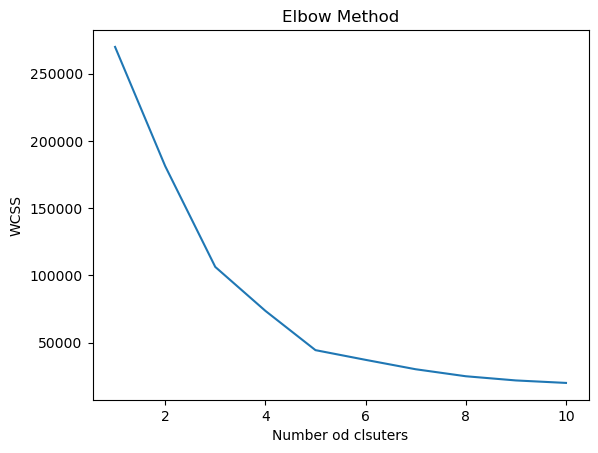

In [9]:
# k =? 
# start with some k=5, k=3

# point -> ideal k value
# Method - Elbow Method - optimal K
# -> involves plotting the number of clusters against the distortion to identify a elbow point
# -> elbow point -> after which the plot curve starts flatteing
# -> represenation of balance b/w clsuter patterns - 

# Steps :
# Calc WCSS (within clsuter sum of clusters) from difff number of clusters (1, 2, 3,....)
# ->WCSS -> cal total sqaured distances of all points within a cluster to their cluster centroid
# -> tells you how spread out the points are within a cluster
# Plot WCSS values - find elbow point - optimal K value

wcss = []
for i in range (1,11) : # i - 1 to 10
    model = KMeans(n_clusters = i, n_init=10, init='k-means++', random_state=42)
    #  n_init=10 -> k means will run 10 times with diff initial centroids and pick the best result
    # init='k-means++' -> smart initialisation technique - fing better cenrtiods and speed up convergence
    model.fit(X)
    wcss.append(model.inertia_)
    # total squared distance of all points from respective cluster centriods
    # how well data points are clustered
    # lower iniertia - points are closer to centriods
    # -> clusters are more tighter abd more compact

plt.plot(range(1,11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number od clsuters')
plt.ylabel('WCSS')
plt.show()

In [11]:
# k=5
model = KMeans(n_clusters = 5, n_init=10, init='k-means++', random_state=42)
model.fit(X)
# Prediction
y_kmeans = model.predict(X)

In [13]:
y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

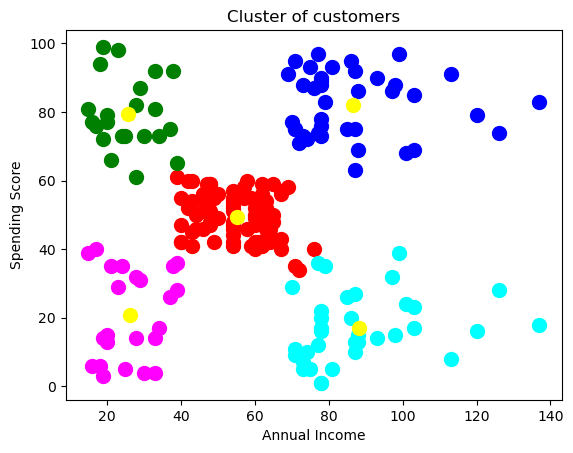

In [23]:
# Plot this 
plt.scatter(X[y_kmeans == 0,0], X[y_kmeans == 0,1], s=100, c='red', label='Cluster1')
# X[y_kmeans == 0,0] - select rows from X where y_kemans=0, take first column
# s=100 -> size of each point
plt.scatter(X[y_kmeans == 1,0], X[y_kmeans == 1,1], s=100, c='blue', label='Cluster2')
plt.scatter(X[y_kmeans == 2,0], X[y_kmeans == 2,1], s=100, c='green', label='Cluster3')
plt.scatter(X[y_kmeans == 3,0], X[y_kmeans == 3,1], s=100, c='cyan', label='Cluster4')
plt.scatter(X[y_kmeans == 4,0], X[y_kmeans == 4,1], s=100, c='magenta', label='Cluster5')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=100, c='yellow', label='Centriods')
plt.title('Cluster of customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

In [ ]:
# Silhouette Score SS
# -> measures how well dat points fit assigned cluster - similarity within cluster, seperated from another cluster
# -> measure two distances 
# 1. Intra clsuter distance -> avg distance b.w points within same cluster -> lower -> compact -> desirable
# 2. Inter cluster distance -> distance b/w clusters -> higher -> clusters are distinct from each other
# Values ranges from -1 to 1
# Close to 1 : object is well clsutered and assingned to appropriate clsuter
# CLose to 0 : object is on boundary of two clusters
# Close to -1 : object is poorly clsutered -> assigned to wrong cluster
# SS -> optimal K value


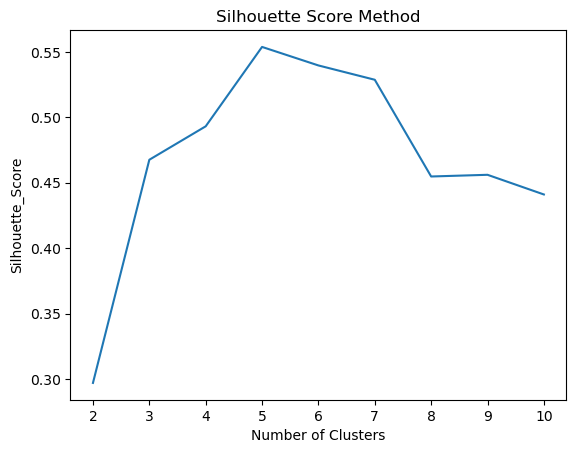

In [25]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for i in range(2,11) :
    model = KMeans(n_clusters = i, n_init=10, init='k-means++', random_state=42)
    model.fit(X)
    score = silhouette_score(X, model.labels_)
    silhouette_scores.append(score)

plt.plot(range(2,11), silhouette_scores)
plt.title('Silhouette Score Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette_Score')
plt.show()


In [ ]:
# Hierarchical Clustering
# -> unlike K-Means -> does not require to specify the number of clausters in advance
# -> build a hierachy of clusters - based on similarity of distance b.w data points
# -> even capture more complex ans nested shapes
# -> provide detailed view of data relationships through a dendgram

# Two approaches :
# 1. Agglomerative Clustering : Bottom to top approach
# 2. Divisive Clustering : Top to bottom approach

In [27]:
# Implement Hierarchical Clustering

df = pd.read_csv('Mall_customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [31]:
# Choose 50 rows, 3-4 as features
df1 = df.iloc[:51, 3:5].values  # 50 rows, cols 3-4 (index)

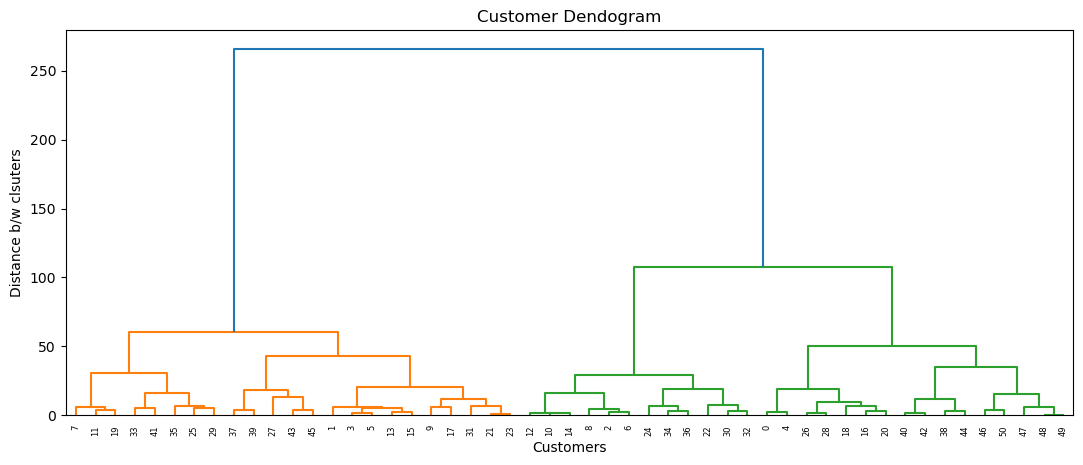

In [33]:
# Create a dendrogram

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(13,5))
plt.title("Customer Dendogram")
dend = shc.dendrogram(shc.linkage(df1, method='ward')) # method='ward' -> how the distances b/w clusters hosuld be computed
                                                       # ward -> minimizes the variance when merging clusters
plt.xlabel("Customers")
plt.ylabel("Distance b/w clsuters")
plt.show()
          

In [41]:
# Agglomerative Clustering 
# -> bottom to top approach

from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
labels_ = model.fit_predict(df1)
labels_

array([4, 0, 2, 0, 4, 0, 2, 3, 2, 0, 2, 3, 2, 0, 2, 0, 4, 0, 4, 3, 4, 0,
       2, 0, 2, 3, 4, 0, 4, 3, 2, 0, 2, 3, 2, 3, 2, 0, 1, 0, 1, 3, 1, 0,
       1, 0, 1, 1, 1, 1, 1], dtype=int64)

Text(0, 0.5, 'Spending Score')

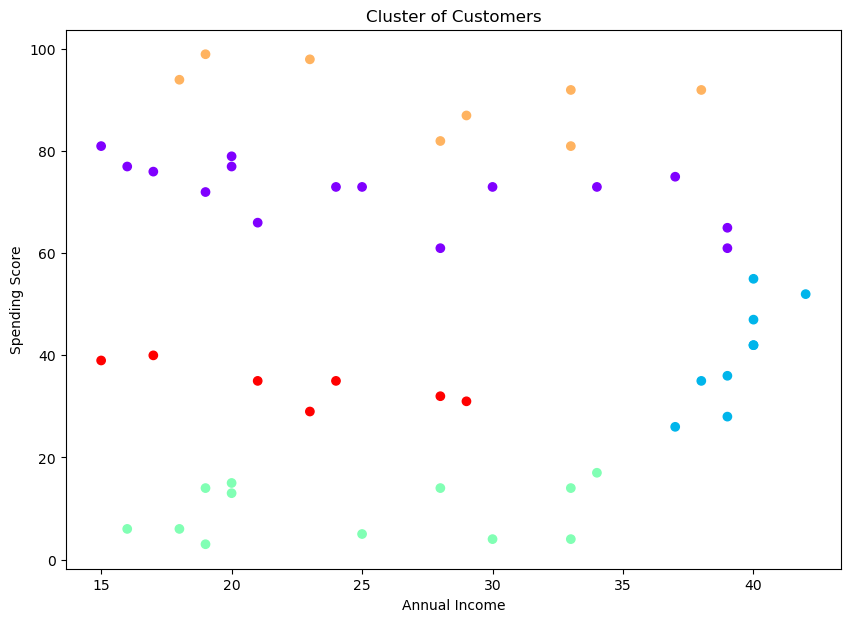

In [49]:
# plot them
plt.figure(figsize=(10,7))
plt.scatter(df1[:,0], df1[:,1], c=model.labels_, cmap='rainbow')
plt.title('Cluster of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

Text(0, 0.5, 'Spending Score')

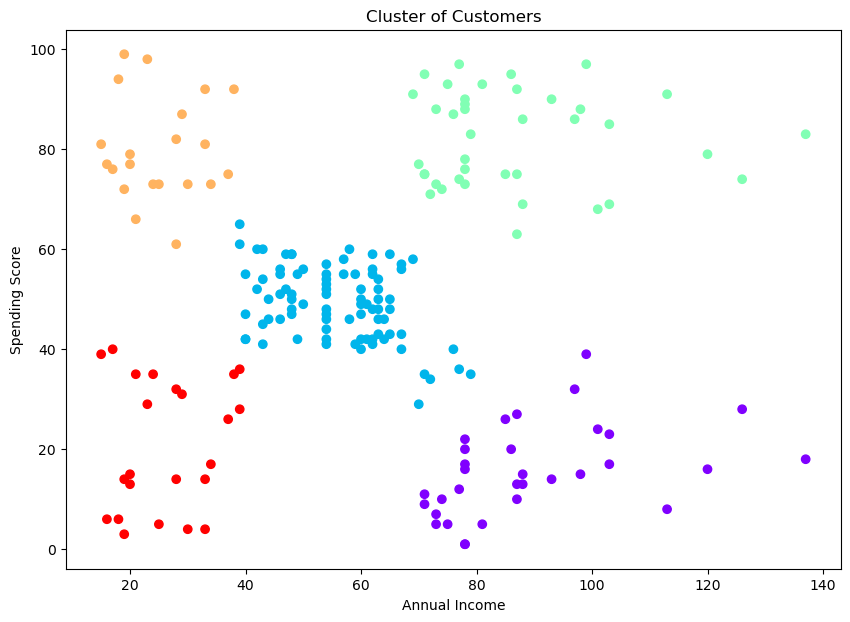

In [51]:
# df2 -> all rows 
df2 = df.iloc[:, 3:5].values 
# try -> paste screenshot

model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
labels_ = model.fit_predict(df2)
labels_

# plot them
plt.figure(figsize=(10,7))
plt.scatter(df2[:,0], df2[:,1], c=model.labels_, cmap='rainbow')
plt.title('Cluster of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

In [53]:
# DBSCAN - Density Based Spatial Clustering of Applicatiosns with Noise

# USL -> clustering task
# goal -> group closely packed data points based on distance
# -> identifies points that are alone in low density regions - outliers, noise
# -> find arbitrarily shaped clusters 
# -> various domains such as anamoly detection, spatial data analysis, image segmenation

df = pd.read_csv('Mall_customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [61]:
from sklearn.model_selection import train_test_split

X = df[['Annual Income (k$)','Spending Score (1-100)']]

# split into trainig and testing sets
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [89]:
# Apply DBSCAN

from sklearn.cluster import DBSCAN

db = DBSCAN(eps=7, min_samples=5).fit(X_train)
# eps=5 -> radius (epsilon neighborhood) - msx distance b.w two points for one to be considered as nieghbor of other
# min_samples=5 -> min no. of points reqd to from a dense region(cluster)
# each cluster should have min 5 points within distance 5 units
labels_train = db.labels_

# Apply to test data
labels_test = db.fit_predict(X_test)
                            

In [91]:
# Number of clusters in labels, noise 
# noise data point -> label is -1

n_clusters_train = len(set(labels_train)) - (1 if -1 in labels_train else 0)
n_noise_train = list(labels_train).count(-1)

n_clusters_test = len(set(labels_test)) - (1 if -1 in labels_test else 0)
n_noise_test = list(labels_test).count(-1)

print(f"Estimated number of clusters (train) : {n_clusters_train}")
print(f"Estimated number of noise points (train) : {n_noise_train}")
print(f"Estimated number of clusters (test) : {n_clusters_test}")
print(f"Estimated number of clusters (test) : {n_noise_test}")

Estimated number of clusters (train) : 4
Estimated number of noise points (train) : 58
Estimated number of clusters (test) : 1
Estimated number of clusters (test) : 26
